# Unit13 Example 04 - 化工案例二：固體觸媒反應速率式

本 Notebook 以 **10 組實驗數據** 示範如何對 Hougen-Watson 型非線性速率模式進行代數線性化，建構設計矩陣，並以最小平方法估計苯氫化反應之動力學參數 $k, K_H, K_B$。

## 學習目標
- 識別 Hougen-Watson 速率式的代數結構，透過取倒數與 $1/4$ 次方完成線性化
- 定義中間變數 $R = \left(P_H^3 P_B / r_0\right)^{1/4}$，建構設計矩陣 $\mathbf{A} = [\mathbf{1},\ P_H,\ P_B]$
- 使用 `scipy.linalg.lstsq()` 求解線性最小平方問題，得到中間參數 $a, b, c$
- 由中間參數反推速率常數： $K_H = b/a$，$K_B = c/a$，$k = a^{-4} K_H^{-3} K_B^{-1}$
- 列印各量測點之實驗值、模式預測值與誤差，驗證模式擬合品質

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit13_Example_04'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit13'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit13
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_04
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_04\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.linalg import lstsq

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述

**化工背景：** 在 $160^\circ\mathrm{C}$ 下，由苯（B）與氫（H）在固體觸媒上合成環己烷，其 Hougen-Watson 型初期反應速率式為：

$$
r_0 = \frac{k K_H^3 K_B P_H^3 P_B}{\left(1 + K_H P_H + K_B P_B\right)^4}
$$

| 符號 | 說明 | 單位 |
|:----:|:-----|:----:|
| $r_0$ | 初期反應速率 | g-mole/(g-cat·hr) |
| $P_H$ | 氫氣分壓 | atm |
| $P_B$ | 苯分壓 | atm |
| $k$ | 表面反應速率常數 | — |
| $K_H$ | 氫氣吸附平衡常數 | atm⁻¹ |
| $K_B$ | 苯吸附平衡常數 | atm⁻¹ |

**目標：** 由 10 組實驗數據估計速率常數 $k$、$K_H$ 及 $K_B$。

In [3]:
# ========================================
# 實驗數據 (160°C, 苯氫化合成環己烷)
# 來源: 呂, 1985
# ========================================
PH = np.array([0.7494, 0.6721, 0.5776, 0.5075, 0.9256,
               0.9266, 0.8766, 0.7564, 0.5617, 0.5241])  # 氫氣分壓 (atm)

PB = np.array([0.2670, 0.3424, 0.4342, 0.5043, 0.1020,
               0.0997, 0.1471, 0.2607, 0.4501, 0.4877])  # 苯分壓 (atm)

r0 = np.array([0.2182, 0.2208, 0.2235, 0.1892, 0.1176,
               0.1151, 0.1472, 0.2178, 0.2122, 0.2024])  # 初期反應速率 (g-mole/g-cat·hr)

n = len(r0)

# 列印數據預覽
print(f"實驗數據共 {n} 組:\n")
print(f"{'No.':>4}  {'PH (atm)':>10}  {'PB (atm)':>10}  {'r0 (g-mole/g·hr)':>18}")
print("-" * 50)
for i in range(n):
    print(f"{i+1:>4}  {PH[i]:>10.4f}  {PB[i]:>10.4f}  {r0[i]:>18.4f}")

實驗數據共 10 組:

 No.    PH (atm)    PB (atm)    r0 (g-mole/g·hr)
--------------------------------------------------
   1      0.7494      0.2670              0.2182
   2      0.6721      0.3424              0.2208
   3      0.5776      0.4342              0.2235
   4      0.5075      0.5043              0.1892
   5      0.9256      0.1020              0.1176
   6      0.9266      0.0997              0.1151
   7      0.8766      0.1471              0.1472
   8      0.7564      0.2607              0.2178
   9      0.5617      0.4501              0.2122
  10      0.5241      0.4877              0.2024


---
### 3. 模式線性化與設計矩陣建構

**線性化步驟：**

1. 速率式兩側同除以 $P_H^3 P_B$ 後取倒數，再取 $1/4$ 次方：

$$
R = \left(\frac{P_H^3 P_B}{r_0}\right)^{1/4} = a + b P_H + c P_B
$$

2. 中間參數定義：

$$
a = \frac{1}{\left(k K_H^3 K_B\right)^{1/4}}, \quad
b = \frac{K_H}{\left(k K_H^3 K_B\right)^{1/4}}, \quad
c = \frac{K_B}{\left(k K_H^3 K_B\right)^{1/4}}
$$

3. 反推公式：$K_H = b/a$，$K_B = c/a$，$k = a^{-4} K_H^{-3} K_B^{-1}$

In [4]:
# ========================================
# 計算線性化中間變數 R
# R = (PH^3 * PB / r0)^(1/4)
# ========================================
R = (PH**3 * PB / r0) ** 0.25

# ========================================
# 建構設計矩陣 A 與目標向量 B
# A: [1, PH, PB]  (10×3)
# B: R             (10,)
# ========================================
A = np.column_stack([np.ones(n), PH, PB])   # shape (10, 3)
B = R                                         # shape (10,)

# 列印 R 值與設計矩陣預覽
print("線性化中間變數 R = (PH³·PB/r0)^(1/4):\n")
print(f"{'No.':>4}  {'PH':>8}  {'PB':>8}  {'r0':>8}  {'R':>10}")
print("-" * 48)
for i in range(n):
    print(f"{i+1:>4}  {PH[i]:>8.4f}  {PB[i]:>8.4f}  {r0[i]:>8.4f}  {R[i]:>10.6f}")

print(f"\n設計矩陣 A (shape = {A.shape}):")
print(f"  [1, PH, PB] (前3行):")
for i in range(3):
    print(f"  [{A[i,0]:.4f}, {A[i,1]:.4f}, {A[i,2]:.4f}]")
print("  ...")

線性化中間變數 R = (PH³·PB/r0)^(1/4):

 No.        PH        PB        r0           R
------------------------------------------------
   1    0.7494    0.2670    0.2182    0.847129
   2    0.6721    0.3424    0.2208    0.828341
   3    0.5776    0.4342    0.2235    0.782210
   4    0.5075    0.5043    0.1892    0.768279
   5    0.9256    0.1020    0.1176    0.910680
   6    0.9266    0.0997    0.1151    0.911117
   7    0.8766    0.1471    0.1472    0.905790
   8    0.7564    0.2607    0.2178    0.848368
   9    0.5617    0.4501    0.2122    0.783013
  10    0.5241    0.4877    0.2024    0.767443

設計矩陣 A (shape = (10, 3)):
  [1, PH, PB] (前3行):
  [1.0000, 0.7494, 0.2670]
  [1.0000, 0.6721, 0.3424]
  [1.0000, 0.5776, 0.4342]
  ...


---
### 4. 最小平方求解與速率常數反推

以 `scipy.linalg.lstsq()` 求解 $\mathbf{A}\boldsymbol{\theta} = \mathbf{B}$ ，得中間參數 $a, b, c$；
再由 $K_H = b/a$，$K_B = c/a$，$k = a^{-4} K_H^{-3} K_B^{-1}$ 反推原始速率常數。

In [5]:
# ========================================
# 最小平方求解: theta = [a, b, c]
# ========================================
theta, residuals, rank, sv = lstsq(A, B)
a, b, c = theta[0], theta[1], theta[2]

# ========================================
# 反推原始速率常數
# ========================================
K_H = b / a
K_B = c / a
k   = (a ** (-4)) * (K_H ** (-3)) * (K_B ** (-1))

# ========================================
# 列印結果
# ========================================
print("=" * 60)
print("   Hougen-Watson 速率模式參數估計結果")
print("=" * 60)
print(f"\n 線性化中間參數:")
print(f"   a = {a:.6f}")
print(f"   b = {b:.6f}")
print(f"   c = {c:.6f}")
print(f"\n 原始速率常數:")
print(f"   K_H = {K_H:.4f}  atm^-1")
print(f"   K_B = {K_B:.4f}  atm^-1")
print(f"   k   = {k:.4f}  g-mole/(g-cat·hr)")
print("=" * 60)
print(f"\n 設計矩陣秩 (rank) = {rank}")
print(f" 奇異值 (singular values): {sv}")

   Hougen-Watson 速率模式參數估計結果

 線性化中間參數:
   a = 0.098782
   b = 0.827773
   c = 0.486528

 原始速率常數:
   K_H = 8.3798  atm^-1
   K_B = 4.9252  atm^-1
   k   = 3.6238  g-mole/(g-cat·hr)

 設計矩陣秩 (rank) = 3
 奇異值 (singular values): [3.99917039e+00 6.62545953e-01 2.85982041e-03]


---
### 5. 模式驗證與誤差分析

以估計所得之 $k, K_H, K_B$ 代回原始 Hougen-Watson 速率式，計算各量測點之模式預測值與誤差：

$$
r_{0,\text{model}} = \frac{k K_H^3 K_B P_H^3 P_B}{\left(1 + K_H P_H + K_B P_B\right)^4}
$$

In [6]:
# ========================================
# 模式預測：代回原始 Hougen-Watson 速率式
# ========================================
r0_model = (k * K_H**3 * K_B * PH**3 * PB) / (1 + K_H * PH + K_B * PB)**4
error    = r0 - r0_model

# ========================================
# 誤差統計
# ========================================
J     = np.sum(error**2)
MAE   = np.mean(np.abs(error))
MaxAE = np.max(np.abs(error))

# ========================================
# 列印比較表
# ========================================
print(f" {'No.':>4}  {'r0_exp':>10}  {'r0_model':>10}  {'error':>10}")
print("-" * 42)
for i in range(n):
    sign = '+' if error[i] >= 0 else ''
    print(f" {i+1:>4}  {r0[i]:>10.4f}  {r0_model[i]:>10.4f}  {sign}{error[i]:>9.4f}")

print("-" * 42)
print(f"\n 誤差平方和 (r0 空間) J = {J:.4e}")
print(f" 平均絕對誤差 (MAE)    = {MAE:.4f}")
print(f" 最大絕對誤差          = {MaxAE:.4f}")

  No.      r0_exp    r0_model       error
------------------------------------------
    1      0.2182      0.2163  +   0.0019
    2      0.2208      0.2280    -0.0072
    3      0.2235      0.2168  +   0.0067
    4      0.1892      0.1932    -0.0040
    5      0.1176      0.1156  +   0.0020
    6      0.1151      0.1135  +   0.0016
    7      0.1472      0.1538    -0.0066
    8      0.2178      0.2144  +   0.0034
    9      0.2122      0.2125    -0.0003
   10      0.2024      0.1998  +   0.0026
------------------------------------------

 誤差平方和 (r0 空間) J = 1.8448e-04
 平均絕對誤差 (MAE)    = 0.0036
 最大絕對誤差          = 0.0072


---
### 6. 繪製實驗值與模式預測值比較圖

✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_04\figs\hw_rate_fitting.png


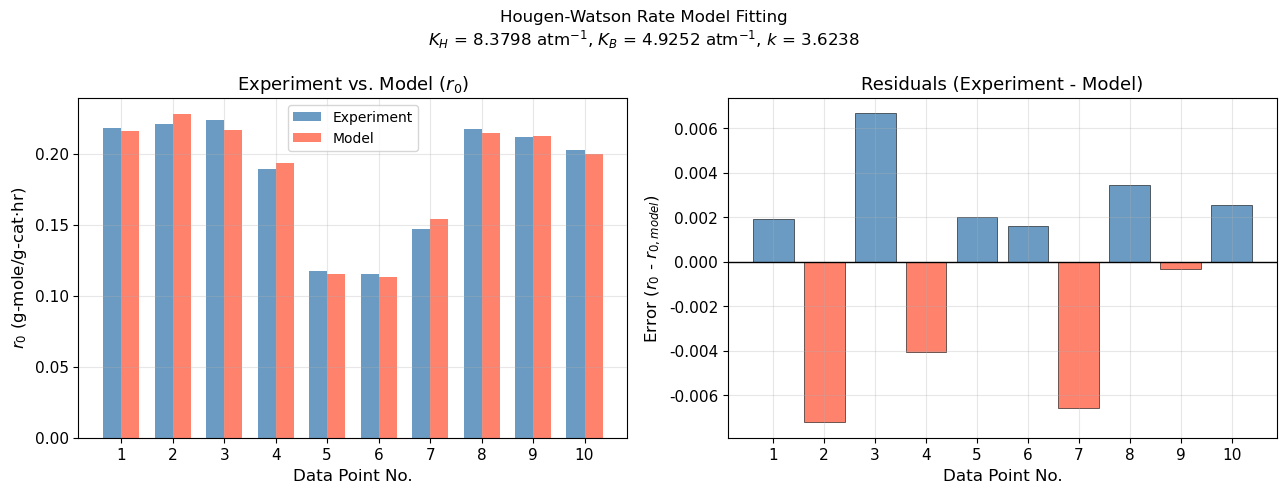

In [7]:
indices = np.arange(1, n + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- 左圖：各點比較 (並排) ----
ax = axes[0]
width = 0.35
ax.bar(indices - width/2, r0,       width, label='Experiment',  color='steelblue',  alpha=0.8)
ax.bar(indices + width/2, r0_model, width, label='Model',       color='tomato',     alpha=0.8)
ax.set_xlabel('Data Point No.')
ax.set_ylabel('$r_0$ (g-mole/g-cat·hr)')
ax.set_title('Experiment vs. Model ($r_0$)')
ax.set_xticks(indices)
ax.legend()

# ---- 右圖：誤差條形圖 ----
ax2 = axes[1]
colors = ['tomato' if e < 0 else 'steelblue' for e in error]
ax2.bar(indices, error, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=1.0)
ax2.set_xlabel('Data Point No.')
ax2.set_ylabel('Error ($r_0$ - $r_{0,model}$)')
ax2.set_title('Residuals (Experiment - Model)')
ax2.set_xticks(indices)

fig.suptitle(
    f'Hougen-Watson Rate Model Fitting\n'
    f'$K_H$ = {K_H:.4f} atm$^{{-1}}$, '
    f'$K_B$ = {K_B:.4f} atm$^{{-1}}$, '
    f'$k$ = {k:.4f}',
    fontsize=12
)

plt.tight_layout()

# 儲存圖檔
fig_path = FIG_DIR / 'hw_rate_fitting.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f"✓ 圖檔已儲存至: {fig_path}")
plt.show()